In [1]:
!pip uninstall -y numpy
!pip install "numpy<2.0"

!pip install torch==2.2.2 torchvision==0.17.2 monai
!pip install scikit-image
!pip install wandb
!pip install import-ipynb
!pip install nibabel 


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/lib/python3.10/shutil.py", line 816, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/lib/python3.10/dist-packages/numpy-1.26.4.dist-info/' -> '/tmp/pip-uninstall-m6spxmqr'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/cli/base_command.py", line 98, in _inner_run
    return self.run(options, args)
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/commands/uninstall.py", line 105, in run
    uninstall_pathset = req.uninstall(
  File "/usr/local/lib/python3.10/dist-packages/pip/_internal/req/req_install.py", line 675, in uninstall
    uninstalle

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import monai
import torch
import re
import torchvision.transforms as transforms
from PIL import Image
from monai.transforms import LoadImage
import import_ipynb
from Functions import patients_dicts
from monai.data import MetaTensor

zip_file = "Resources.zip"
os.makedirs("train", exist_ok=True)
!unzip -o -q {zip_file} -d {"train"}
data_path = "train"

train_dict_list = patients_dicts(data_path)

In [3]:
class MedMNISTData(monai.data.Dataset):
    
    def __init__(self, datafile, transform=None):
        self.data = datafile
        self.transform = transform
        
        
    def __getitem__(self, index):
        transform_dict = self.data[index]
        
        if self.transform:
            transform_dict = self.transform(transform_dict)
        return transform_dict
    
    def __len__(self):
        return len(self.data)

In [4]:
from monai.transforms import LoadImaged, Compose, EnsureChannelFirstd,ScaleIntensityd, Spacingd,LoadImaged, ResizeWithPadOrCropd

data_transform = Compose([
    LoadImaged(keys=["imgED", "maskED", "imgES", "maskES"], image_only=False),
    EnsureChannelFirstd(keys=["imgED","maskED","imgES","maskES"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["imgED", "imgES", ])
])

train_dataset = MedMNISTData(train_dict_list, transform=data_transform)

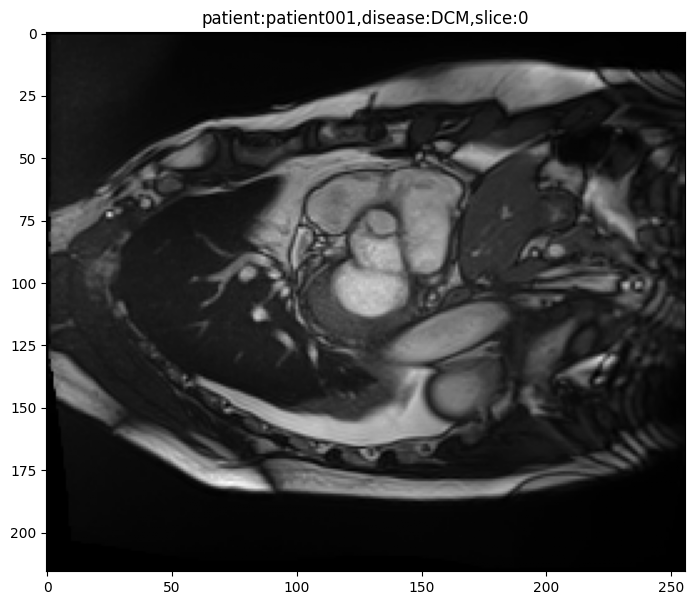

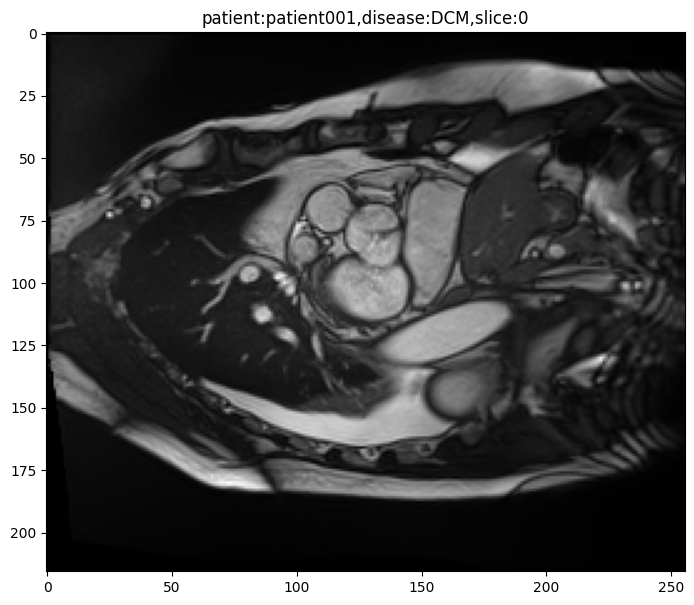

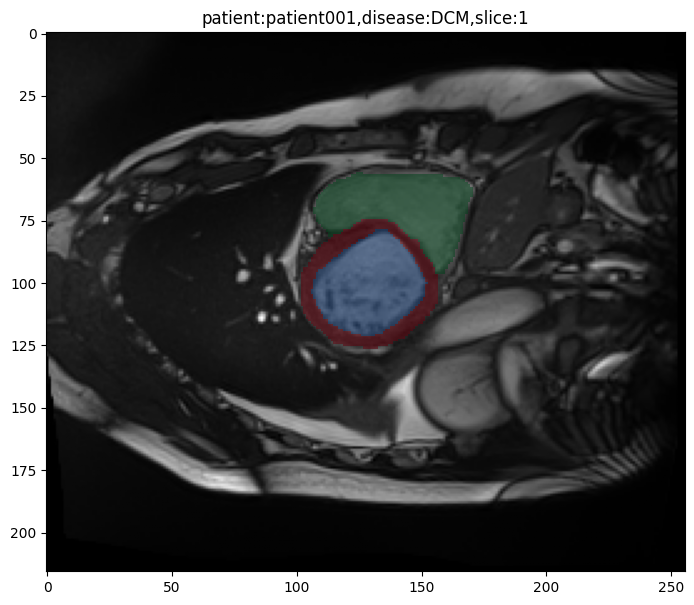

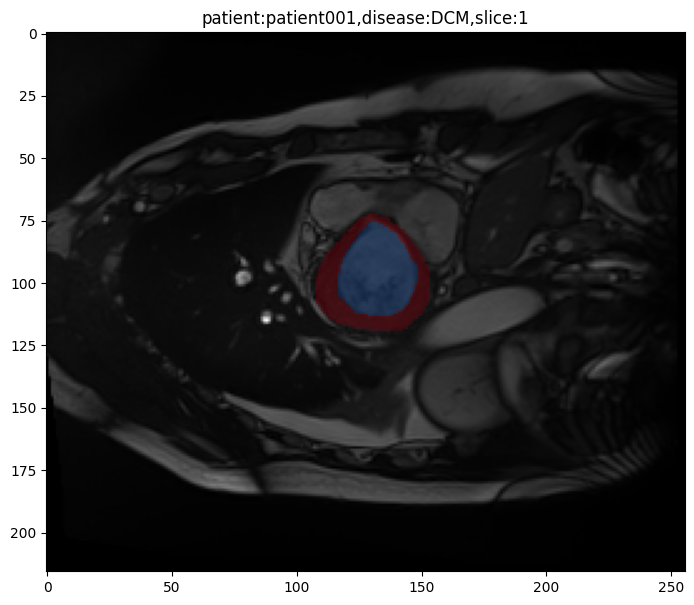

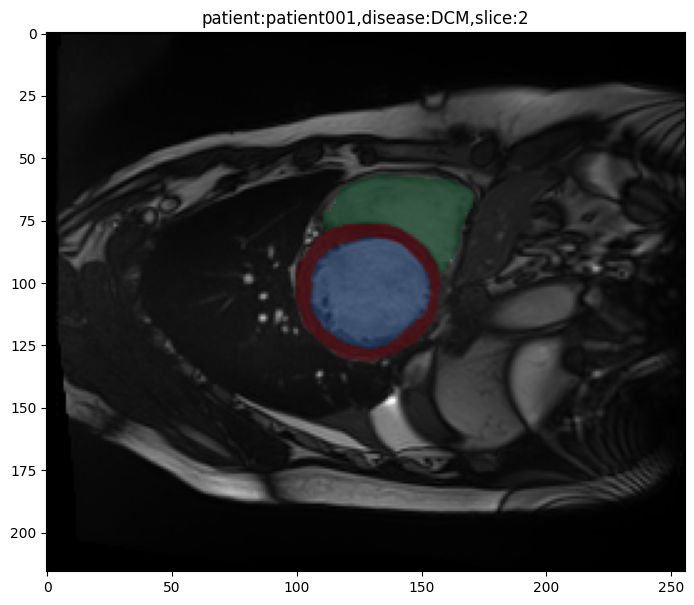

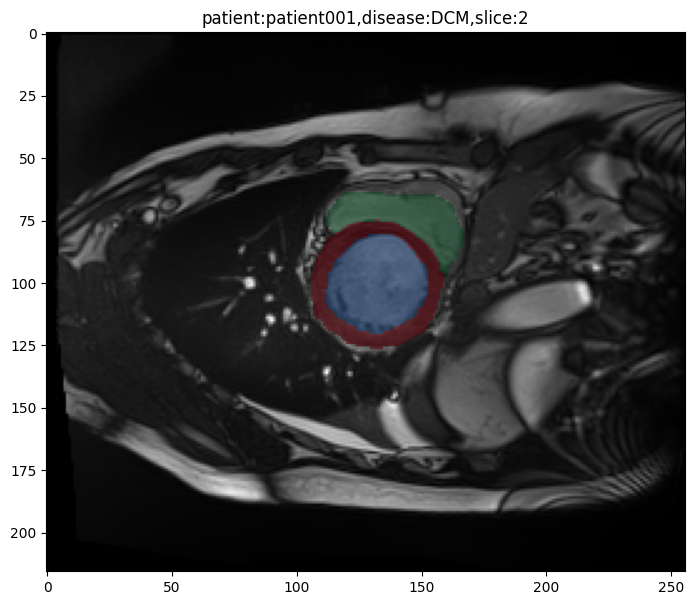

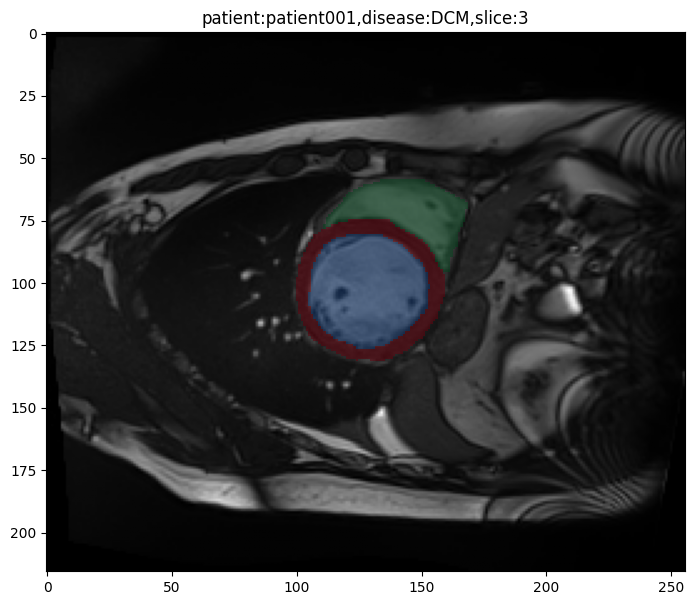

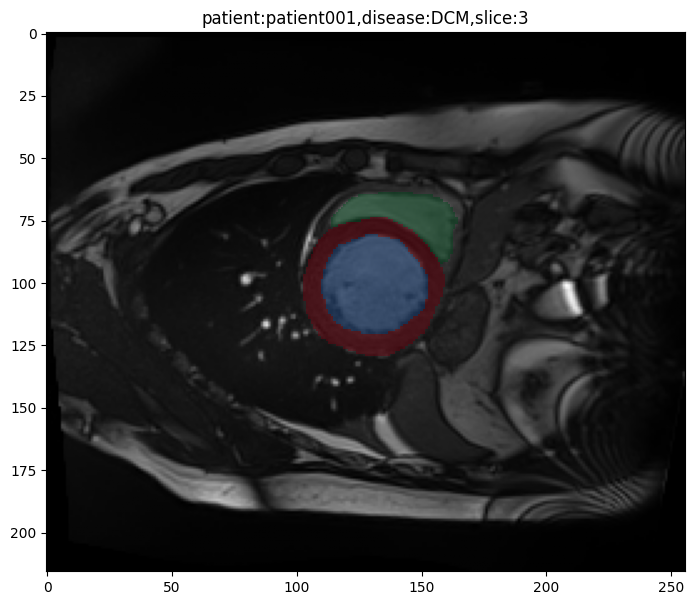

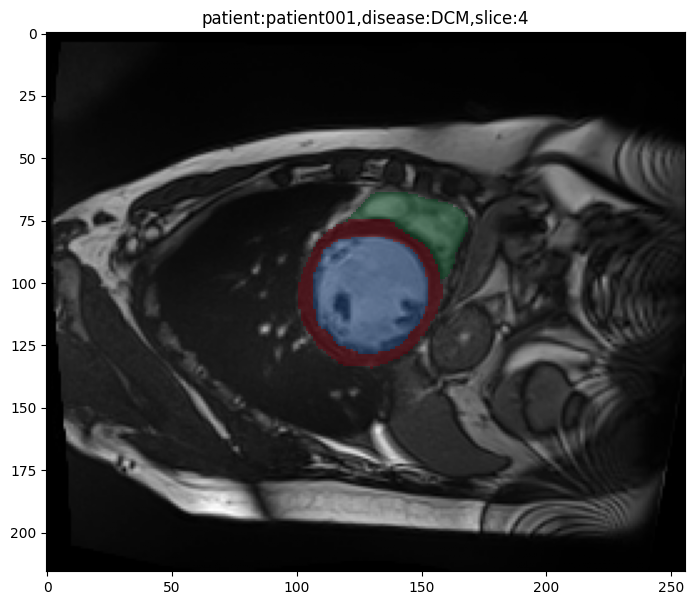

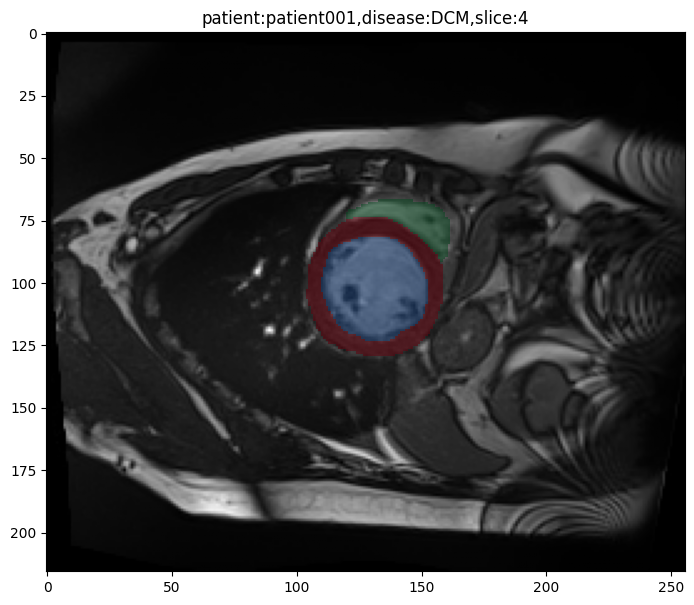

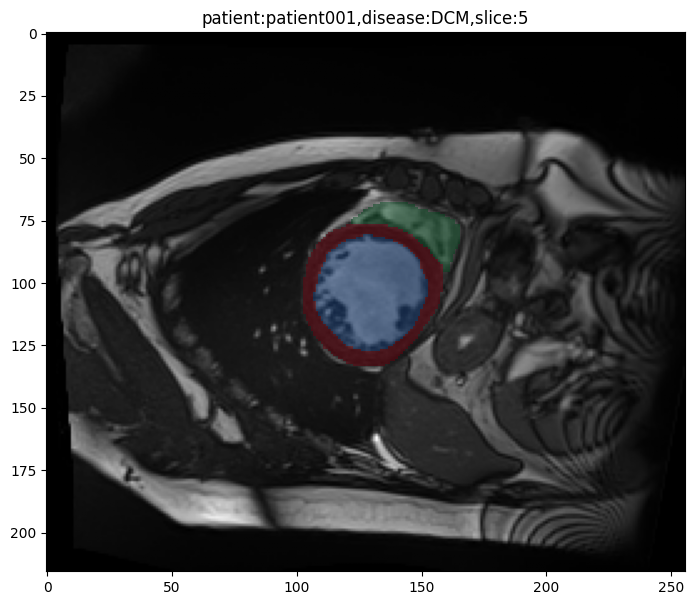

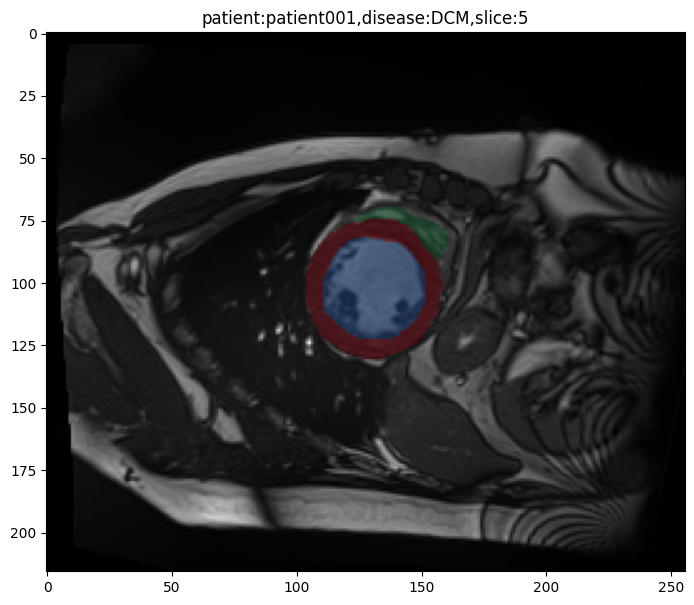

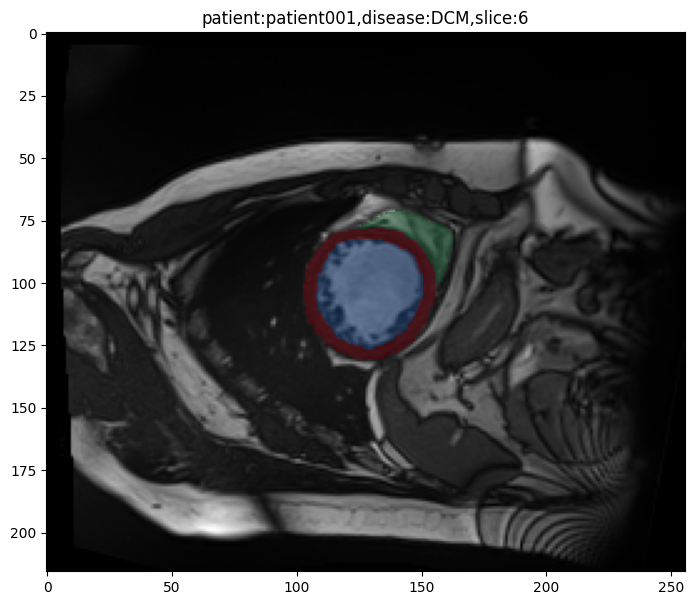

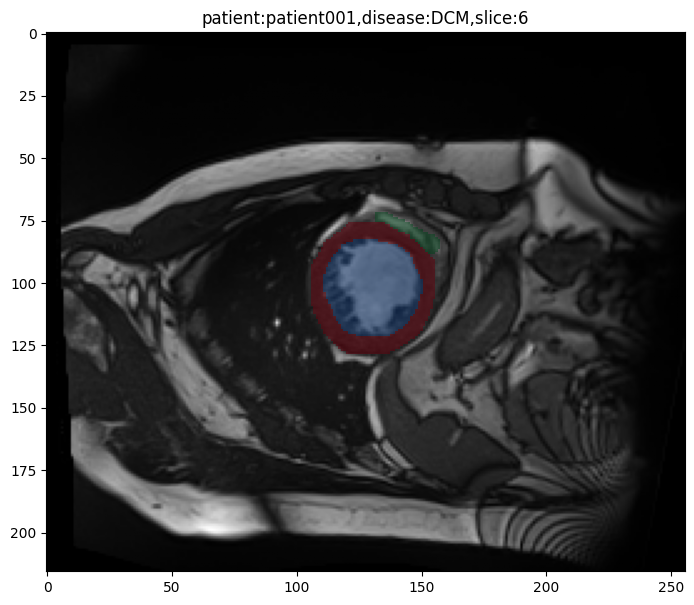

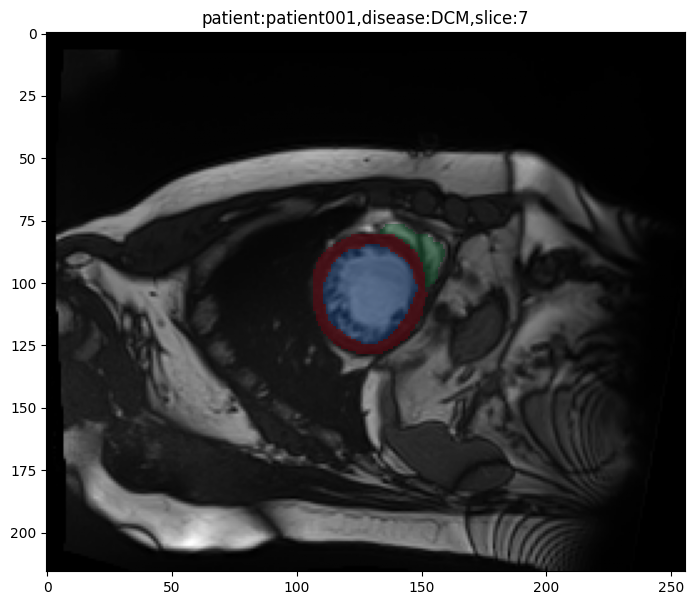

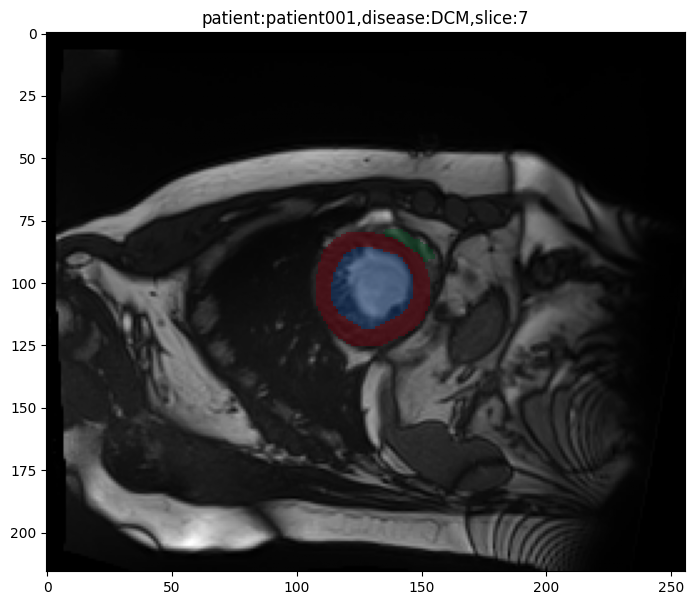

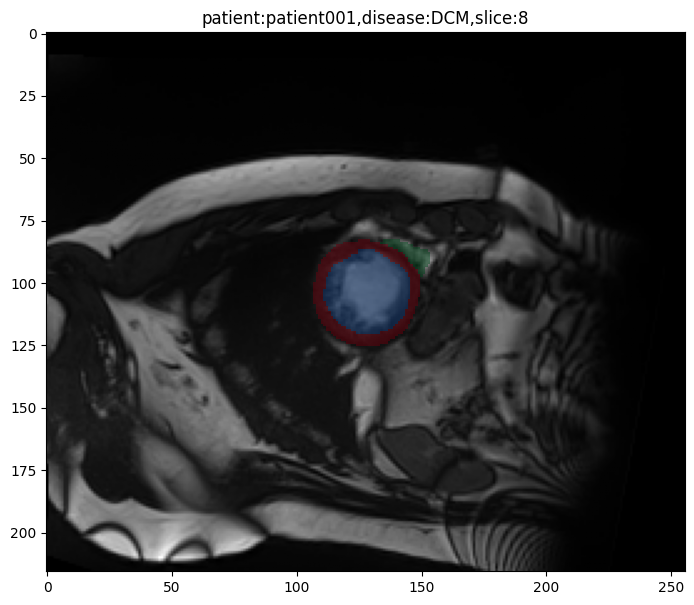

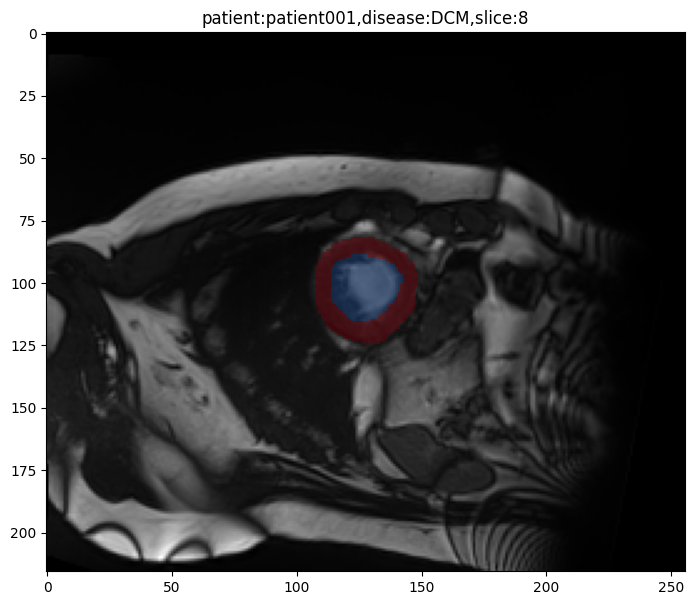

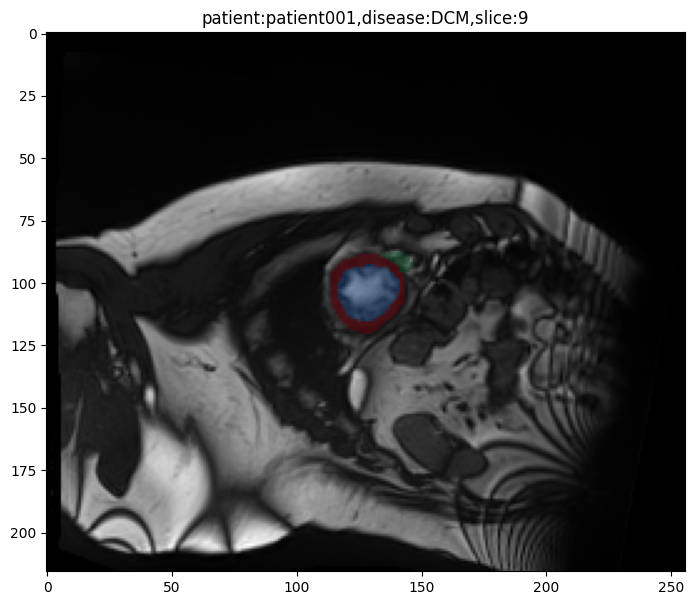

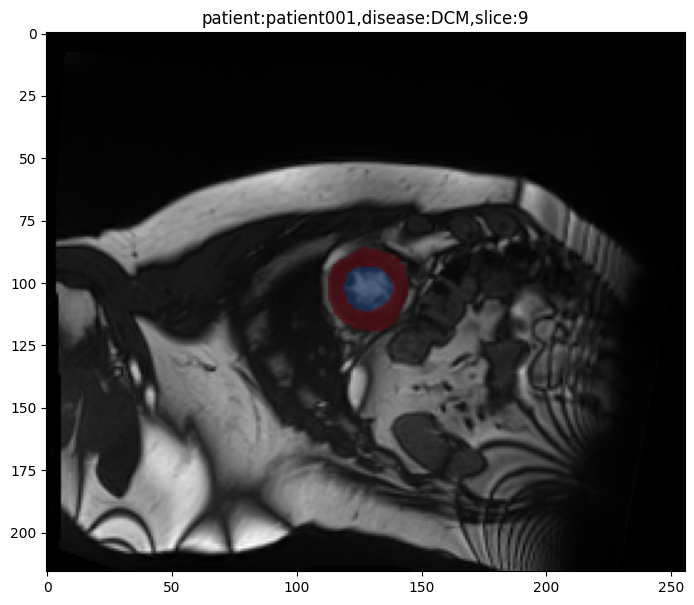

In [5]:
def visualize_heart_sample(sample, title=None):
    # Visualize the x-ray and overlay the mask, using the dictionary as input
    for i in range(2):
        if i == 0:
            image = np.squeeze(sample['imgED'])
            mask = np.squeeze(sample['maskED'])
        else:
            image = np.squeeze(sample['imgES'])
            mask = np.squeeze(sample['maskES'])

        plt.figure(figsize=[10,7])
        plt.imshow(image, 'gray')

        mask1 = np.ma.masked_where(mask != 1, mask)
        plt.imshow(mask1, 'Greens', alpha = 0.5, clim=[0,1], interpolation='nearest')

        mask2 = np.ma.masked_where(mask != 2, mask)
        plt.imshow(mask2, 'Reds', alpha = 0.5, clim=[0,1], interpolation='nearest')

        mask3 = np.ma.masked_where(mask != 3, mask)
        plt.imshow(mask3, 'Blues', alpha = 0.5, clim=[0,1], interpolation='nearest')
        if title is not None:
            plt.title(title)
        plt.show()

shape = train_dataset[0]['imgED'].shape
for i in range(shape[3]):
    single_data = train_dataset[0]
    sample_slice = {
    'imgED': single_data['imgED'][0,:, :, i],
    'maskED': single_data['maskED'][0,:, :, i],
    'imgES': single_data['imgES'][0,:, :, i],
    'maskES': single_data['maskES'][0,:, :, i]
    }
    visualize_heart_sample(sample_slice, title=f"patient:{single_data['ID']},disease:{single_data['Disease']},slice:{i}")